In [92]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")
from skew_correction import full_correction

import numpy as np
import os 
import sys
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
from astropy.visualization import ImageNormalize, AsinhStretch
from juanfit import gaussian
from plotting_modules import doppler_plot, amplitude_plot
from skew_parameter_search import detrend_dopp
from fancy_colorbar import plot_colorbar

from matplotlib.animation import FuncAnimation
from astropy.visualization import (ImageNormalize, AsinhStretch,
                                   ) 
from IPython.display import HTML, display

In [2]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20231017T171033_V22_218104106-000.fits"

with fits.open(spice_file) as hdul:
    # hdul.info()
    spice_NeVIII_data = hdul[1].data[0].copy()
    spice_NeVIII_header = hdul[1].header.copy()
    spice_CIII_data = hdul[4].data[0].copy()
    spice_CIII_header = hdul[4].header.copy()
spice_NeVIII_data = spice_NeVIII_data.T
spice_CIII_data = spice_CIII_data.T
# spice_NeVIII_header["NAXIS1"] = 60
# spice_NeVIII_header["NAXIS2"] = 240
# spice_NeVIII_data = spice_NeVIII_data[30:90,240:480,:]

In [3]:
spice_NeVIII_data.shape, spice_CIII_data.shape

((192, 836, 25), (192, 836, 17))

In [4]:
NeVIII_wvl = spice_NeVIII_header["CRVAL3"] + \
spice_NeVIII_header["CDELT3"] * (np.arange(1, spice_NeVIII_header["NAXIS3"]+1) - spice_NeVIII_header["CRPIX3"])
NeVIII_wvl = NeVIII_wvl*10
CIII_wvl = spice_CIII_header["CRVAL3"] + \
spice_CIII_header["CDELT3"] * (np.arange(1, spice_CIII_header["NAXIS3"]+1) - spice_CIII_header["CRPIX3"])
CIII_wvl = CIII_wvl*10

In [5]:
raw_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, 0, 0, nthreads=12, linelist={'C III 977':977.0})

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [6]:
raw_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, 0, 0, nthreads=12, linelist={'Ne VIII 770':770.4})

In [7]:
def correction_preview(best_correction_results):
    plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

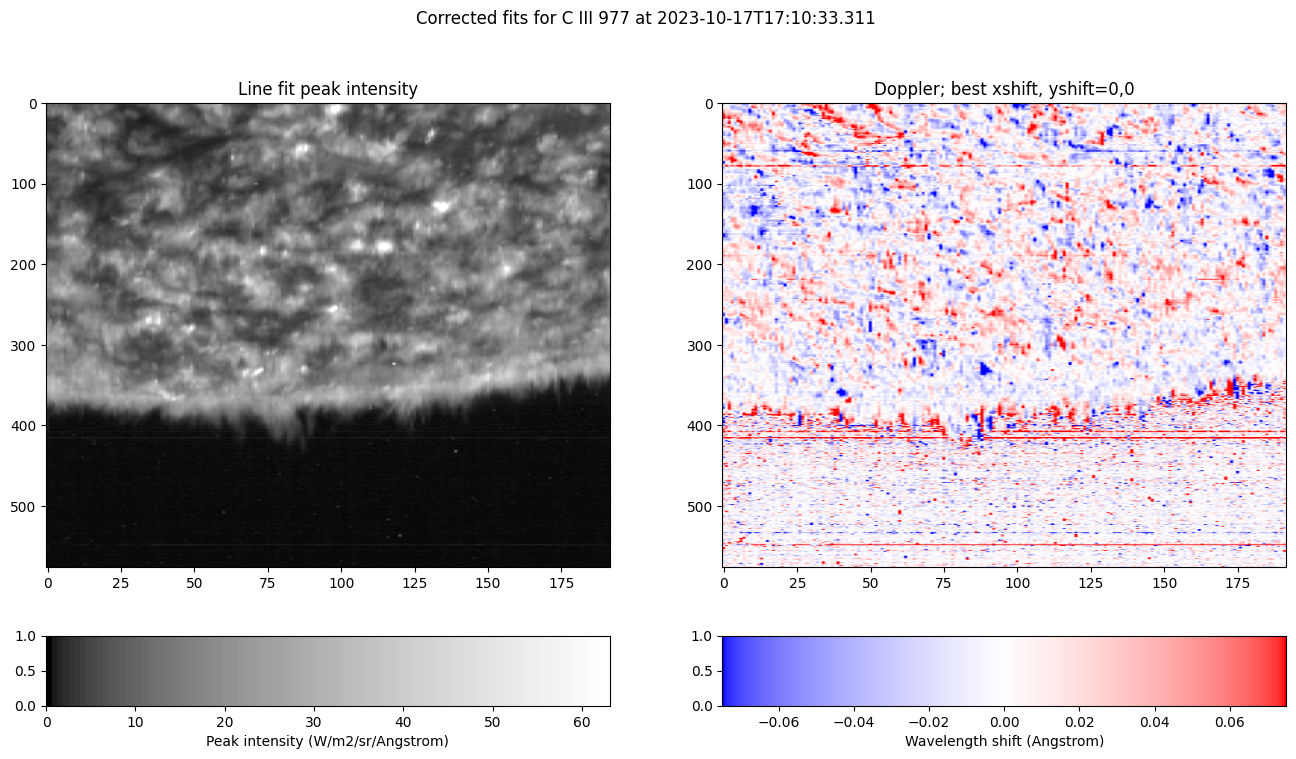

In [8]:
correction_preview(raw_results_CIII)

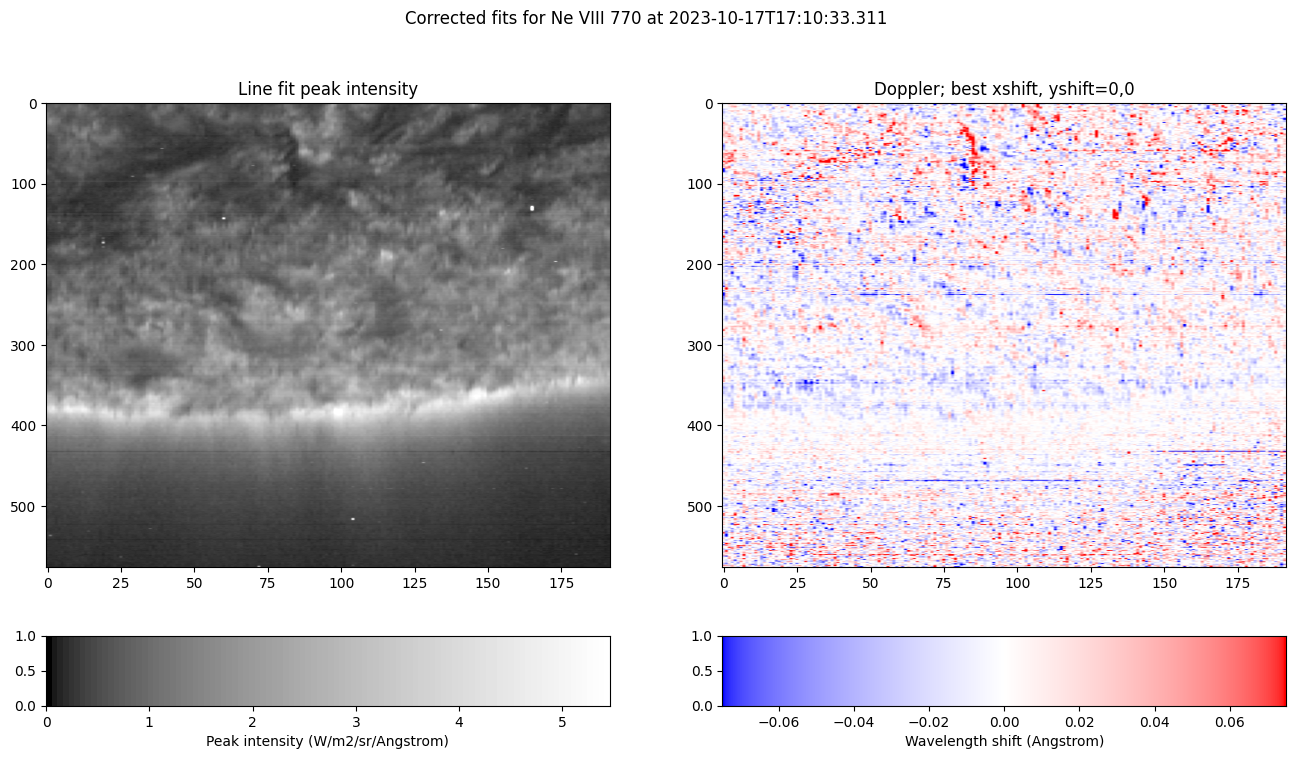

In [9]:
correction_preview(raw_results_NeVIII)

In [10]:
best_skew_x_CIII, best_skew_y_CIII = 3., -1.667

best_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, best_skew_x_CIII, best_skew_y_CIII, nthreads=12)

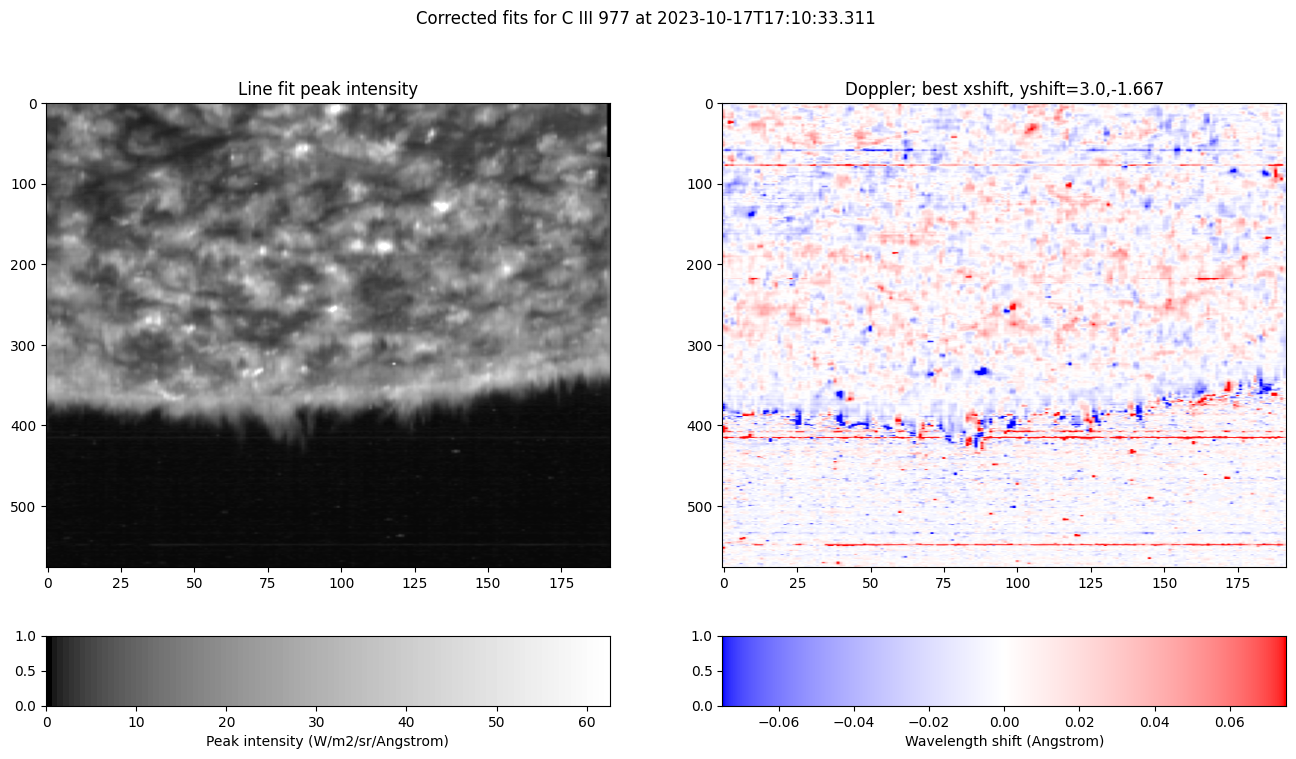

In [11]:
correction_preview(best_correction_results_CIII)

In [14]:
best_skew_x_NeVIII, best_skew_y_NeVIII = 2.667, -2.

best_correction_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x_NeVIII, best_skew_y_NeVIII, nthreads=12,
                                                linelist={'Ne VIII 770':770.4})

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


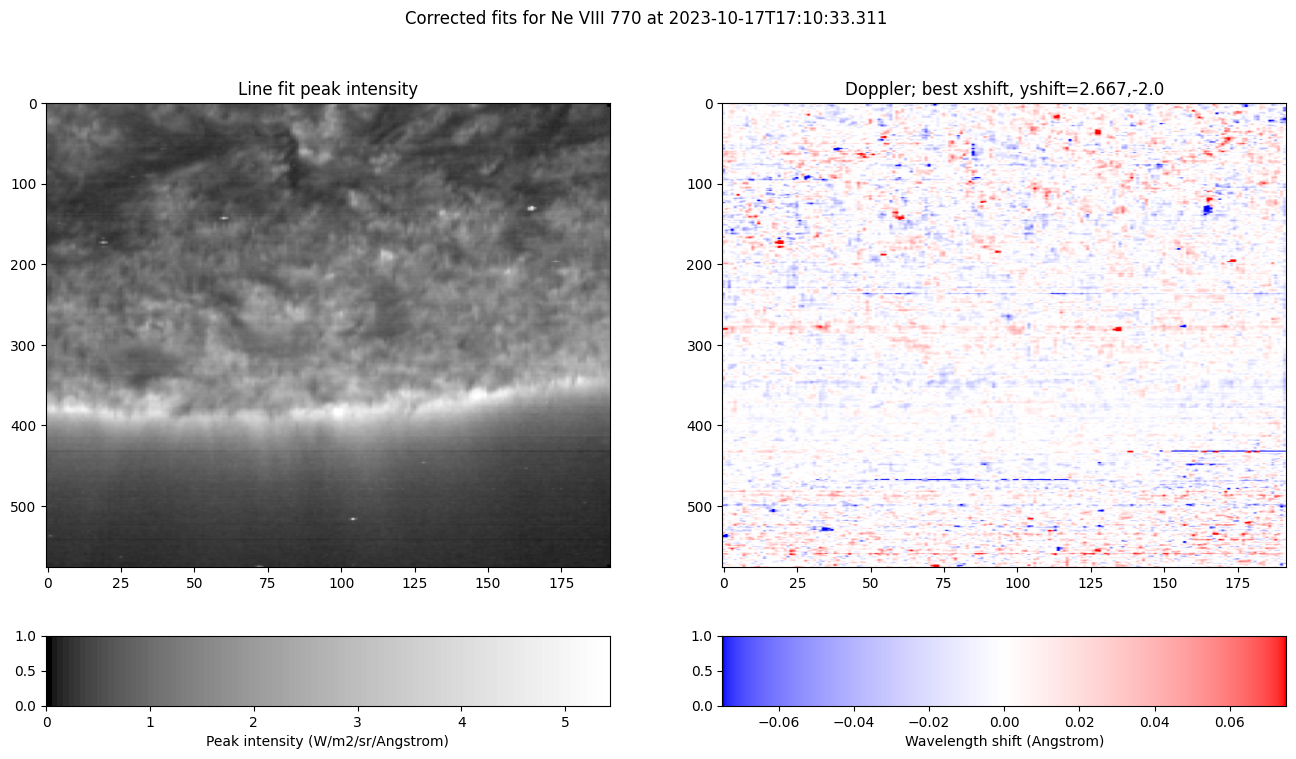

In [15]:
correction_preview(best_correction_results_NeVIII)

In [17]:
np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231017/raw_CIII_results.npz", **raw_results_CIII)
np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231017/raw_NeVIII_results.npz", **raw_results_NeVIII)
np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231017/best_CIII_results.npz", **best_correction_results_CIII)
np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231017/best_NeVIII_results.npz", **best_correction_results_NeVIII)

In [25]:
raw_results_CIII.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [73]:
raw_CIII_int = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
raw_CIII_vel = detrend_dopp(raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
raw_CIII_vel_err = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
raw_CIII_vel_mask = np.abs(raw_CIII_vel_err) > 0.025
raw_CIII_vel[raw_CIII_vel_mask] = np.nan
raw_CIII_vel = raw_CIII_vel - np.nanmedian(raw_CIII_vel[:300, :])
raw_CIII_vel = raw_CIII_vel/977.020*const.c.to_value(u.km/u.s)

skew_CIII_int = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
skew_CIII_vel = detrend_dopp(best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
skew_CIII_vel_err = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
skew_CIII_vel_mask = np.abs(skew_CIII_vel_err) > 0.025
skew_CIII_vel[skew_CIII_vel_mask] = np.nan
skew_CIII_vel = skew_CIII_vel - np.nanmedian(skew_CIII_vel[:300, :])
skew_CIII_vel = skew_CIII_vel/977.020*const.c.to_value(u.km/u.s)

In [43]:
detrend_dopp(raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers']).shape

(192, 836)

In [38]:
raw_results_CIII['linefits']['C III 977 - Peak']['C III 977'].keys()

dict_keys(['amplitudes', 'centers', 'sigmas'])

In [76]:
raw_results_CIII['dat_skew'].shape

(192, 836, 17)

In [105]:
def play_data(data, aspect=1, vmin_perc=0.5, vmax_perc=99.5, fps=3, save_filename=None):
    nx, ny, nl = data.shape

    fig, ax = plt.subplots(1,1,figsize=(6,6))
    im = ax.imshow(data[:,:,0].T, aspect=aspect, interpolation='none',
                   norm=ImageNormalize(vmin=np.nanpercentile(data[:,:,0], vmin_perc),
                                       vmax=np.nanpercentile(data[:,:,0], vmax_perc),
                                       stretch=AsinhStretch(0.1)),
                   origin="lower")

    def update(i):
        im.set_array(data[:,:,i].T)
        im.set_norm(ImageNormalize(vmin=np.nanpercentile(data[:,:,i], vmin_perc),
                                   vmax=np.nanpercentile(data[:,:,i], vmax_perc),
                                   stretch=AsinhStretch(0.1)))
        return im
    
    anim = FuncAnimation(fig, update, frames=nl, interval=1000/fps, repeat=True)
    anim_html = HTML(anim.to_jshtml())

    if save_filename is not None:
        anim.save(save_filename, writer='imagemagick', fps=fps)

    fig.clf()
    plt.close()

    display(anim_html)

In [106]:
play_data(raw_results_CIII['dat_skew'][40:80,240:240+120], aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'],
          save_filename="../../figs/CIII_test.gif")

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Text(0.5, 0.98, 'C III 977 - Peak 2023-10-17T17:10:33.311')

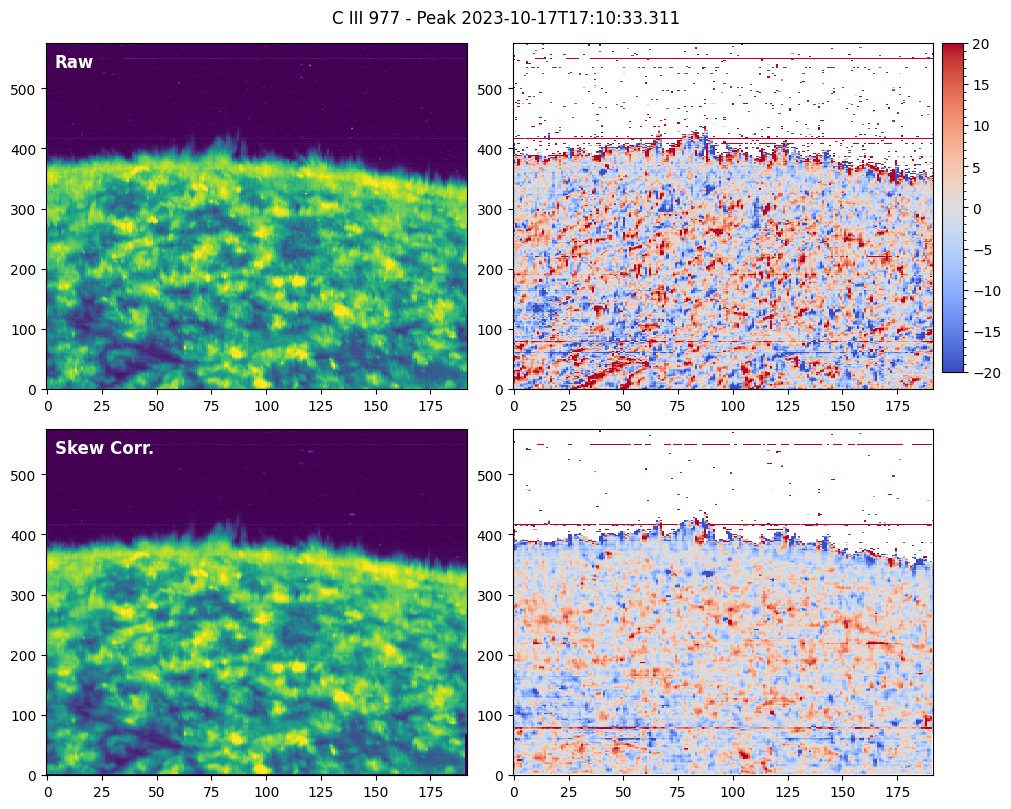

In [97]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_CIII_int, 0.5),
                               vmax=np.nanpercentile(raw_CIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 0.5),
                               vmax=np.nanpercentile(skew_CIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_CIII_header['EXTNAME'] + " " +spice_CIII_header['DATE-BEG'], fontsize=12)




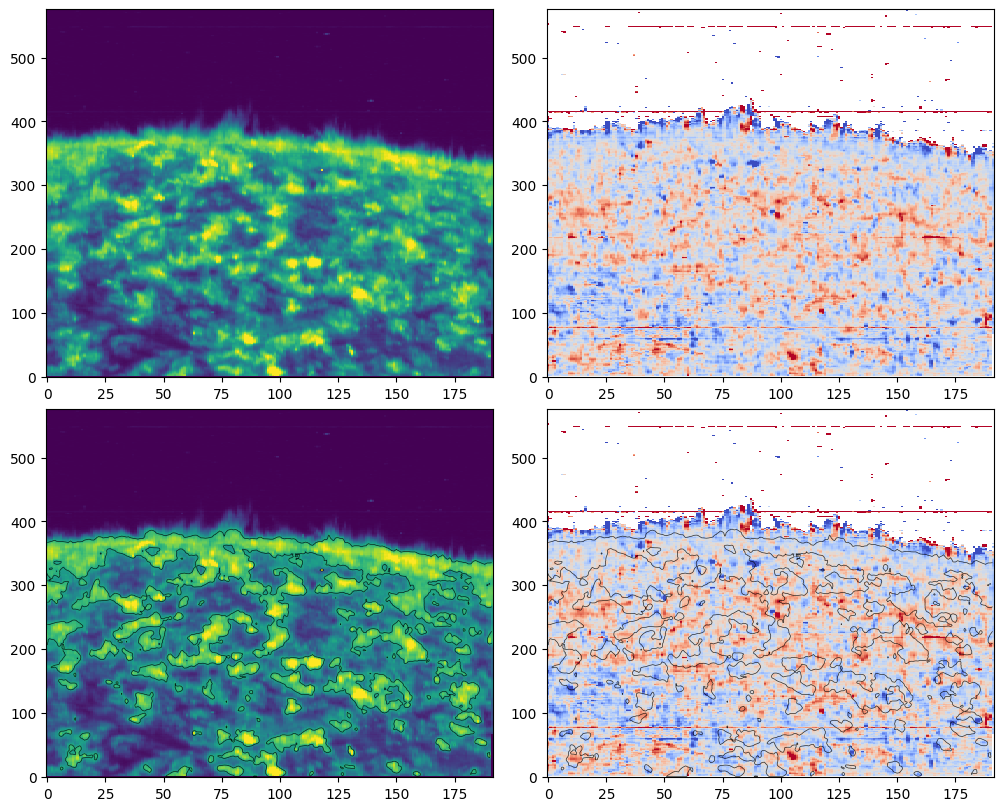

In [121]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(10,8), layout="constrained")

im1 = ax1.imshow(skew_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 1),
                               vmax=np.nanpercentile(skew_CIII_int, 99.5),
                               stretch=AsinhStretch(0.3)))



im2 = ax2.imshow(skew_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")


im3 = ax3.imshow(skew_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 1),
                               vmax=np.nanpercentile(skew_CIII_int, 99.5),
                               stretch=AsinhStretch(0.3)))

for ax_ in (ax3,ax4):
    ax_.contour(skew_CIII_int, [np.nanpercentile(skew_CIII_int, 80)], linewidths=0.5, alpha=0.8, colors="black")

im4 = ax4.imshow(skew_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")



In [102]:
raw_NeVIII_int = raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
raw_NeVIII_vel = detrend_dopp(raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
raw_NeVIII_vel_err = raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
raw_NeVIII_vel_mask = np.abs(raw_NeVIII_vel_err) > 0.025
raw_NeVIII_vel[raw_NeVIII_vel_mask] = np.nan
raw_NeVIII_vel = raw_NeVIII_vel - np.nanmedian(raw_NeVIII_vel[:300, :])
raw_NeVIII_vel = raw_NeVIII_vel/770.428*const.c.to_value(u.km/u.s)

skew_NeVIII_int = best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
skew_NeVIII_vel = detrend_dopp(best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
skew_NeVIII_vel_err = best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
skew_NeVIII_vel_mask = np.abs(skew_NeVIII_vel_err) > 0.025
skew_NeVIII_vel[skew_NeVIII_vel_mask] = np.nan
skew_NeVIII_vel = skew_NeVIII_vel - np.nanmedian(skew_NeVIII_vel[:300, :])
skew_NeVIII_vel = skew_NeVIII_vel/770.428*const.c.to_value(u.km/u.s)

Text(0.5, 0.98, 'Ne VIII 770 - Peak 2023-10-17T17:10:33.311')

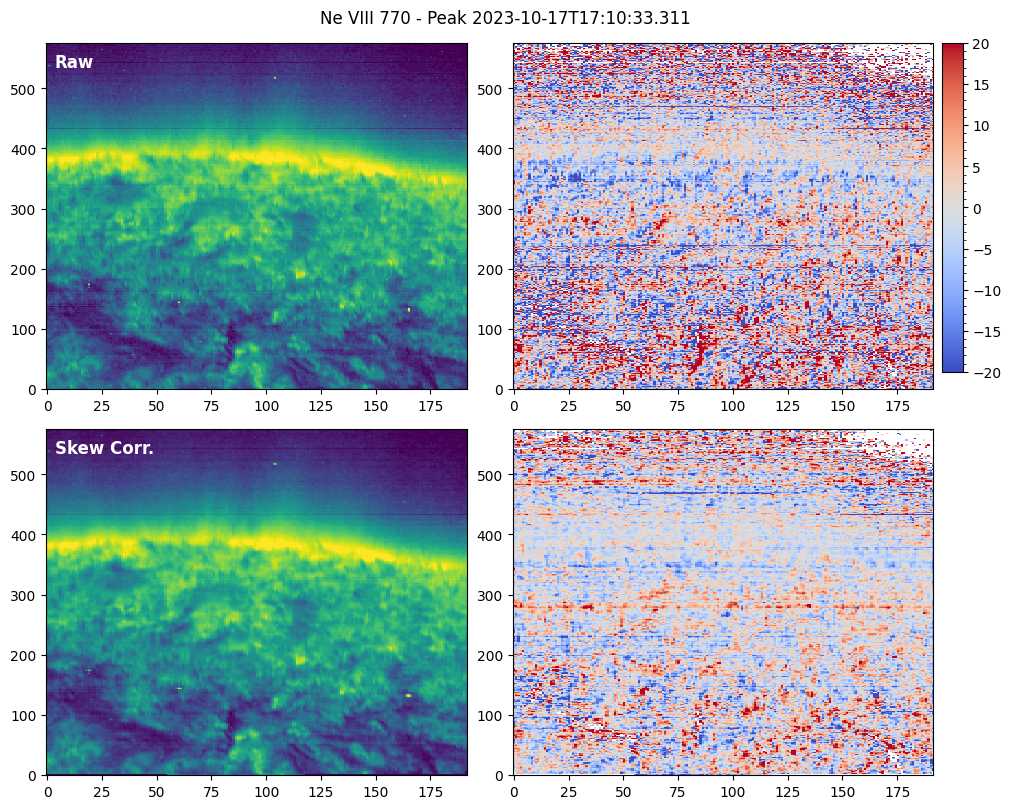

In [103]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(raw_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(skew_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_NeVIII_header['EXTNAME'] + " " +spice_NeVIII_header['DATE-BEG'], fontsize=12)




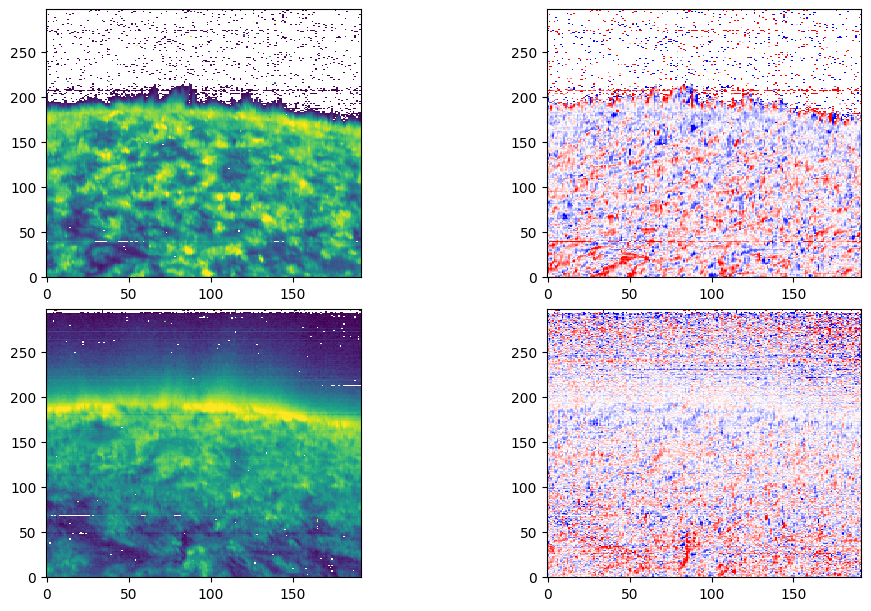

In [21]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,6), layout="constrained")

ax1.imshow(CIII_raw_fit_int, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(CIII_raw_fit_int, 0.5),
                                vmax=np.nanpercentile(CIII_raw_fit_int, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax2.imshow((CIII_raw_fit_wvl - np.nanmedian(CIII_raw_fit_wvl, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')


ax3.imshow(NeVIII_raw_fit_int, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_raw_fit_int, 0.5),
                                vmax=np.nanpercentile(NeVIII_raw_fit_int, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax4.imshow((NeVIII_raw_fit_wvl - np.nanmedian(NeVIII_raw_fit_wvl, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')



In [22]:
best_skew_x_CIII, best_skew_y_CIII = 3.333, -2.0

best_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, best_skew_x_CIII, best_skew_y_CIII, nthreads=12)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [32]:
best_correction_results_CIII.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [29]:
def correction_preview(best_correction_results):
    plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

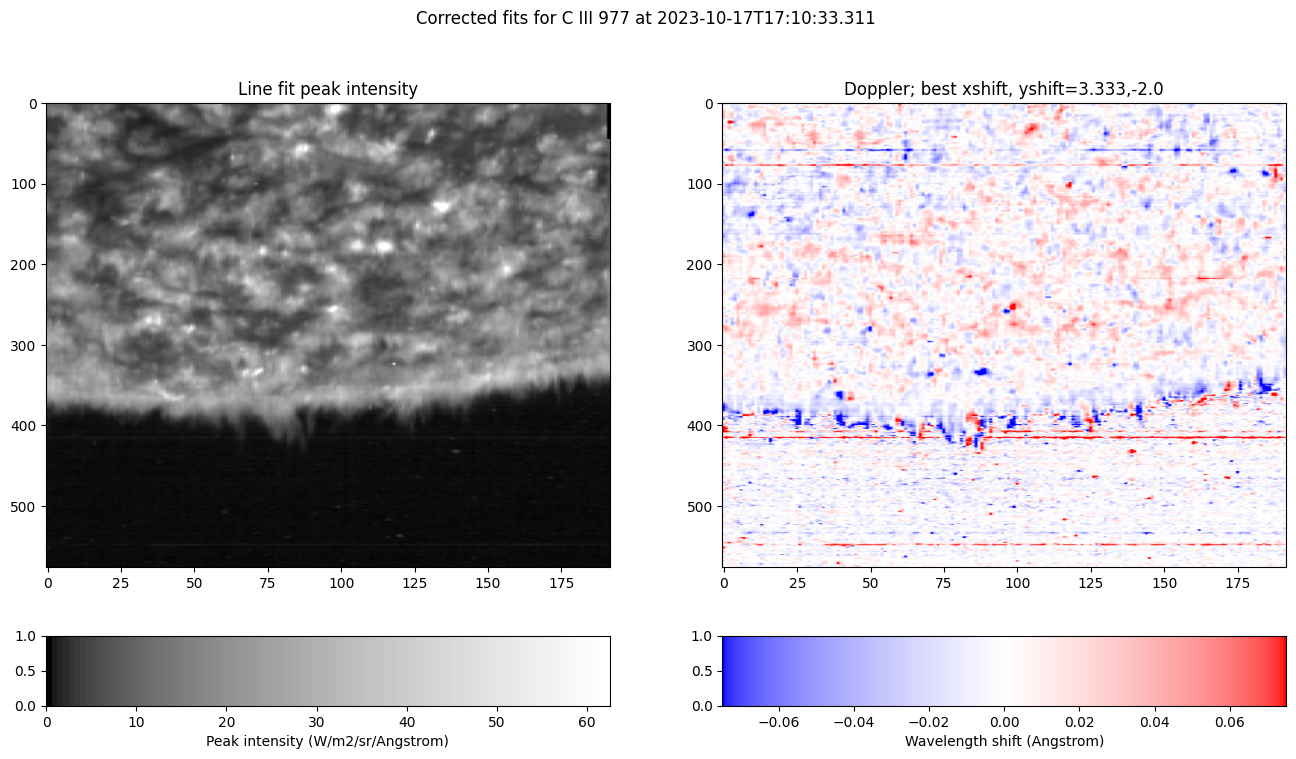

In [30]:
correction_preview(best_correction_results_CIII)

In [25]:
best_skew_x_NeVIII, best_skew_y_NeVIII = 3., -2.333

best_correction_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x_NeVIII, best_skew_y_NeVIII, nthreads=12)

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [56]:
dat_skew_rebin = best_correction_results['dat_skew'].T
dat_skew_rebin = dat_skew_rebin[:,120:-120,:]
dat_skew_rebin = np.nanmean(dat_skew_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)

/scratch/tmp.29353421.zhuyin/ipykernel_83327/1000474420.py:3: RuntimeWarning: Mean of empty slice
  dat_skew_rebin = np.nanmean(dat_skew_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)


In [57]:
dat_skew_rebin.shape

(25, 298, 192)

In [58]:
(NeVIII_skew_fit_wvl_r1, NeVIII_skew_fit_int_r1, NeVIII_skew_fit_wid_r1,
NeVIII_skew_fit_b_r1) = fit_parallel(best_correction_results['waves'],
                                     dat_skew_rebin,
                                     0*np.ones(dat_skew_rebin.shape[1:], dtype=int),
                                     24*np.ones(dat_skew_rebin.shape[1:], dtype=int))

In [60]:
dat_raw_rebin = spice_NeVIII_data.T
dat_raw_rebin = dat_raw_rebin[:,120:-120,:]
dat_raw_rebin = np.nanmean(dat_raw_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)

/scratch/tmp.29353421.zhuyin/ipykernel_83327/2019165435.py:3: RuntimeWarning: Mean of empty slice
  dat_raw_rebin = np.nanmean(dat_raw_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)


In [61]:
(NeVIII_raw_fit_wvl_r1, NeVIII_raw_fit_int_r1, NeVIII_raw_fit_wid_r1,
NeVIII_raw_fit_b_r1) = fit_parallel(best_correction_results['waves'],
                                     dat_raw_rebin,
                                     0*np.ones(dat_raw_rebin.shape[1:], dtype=int),
                                     24*np.ones(dat_raw_rebin.shape[1:], dtype=int))

In [64]:
plot_aspect = best_correction_results['hdr']['CDELT2']/best_correction_results['hdr']['CDELT1']*2

Text(0, 0.5, 'Raw')

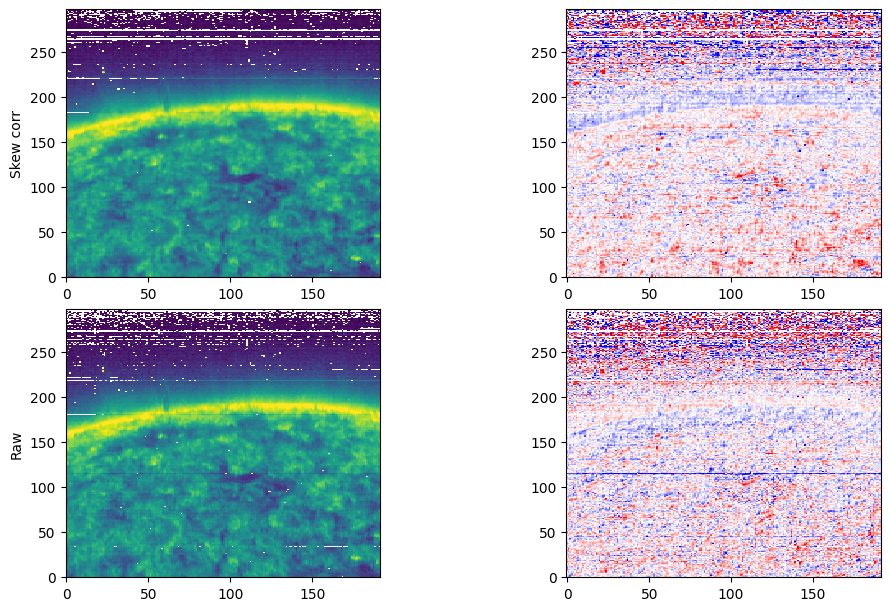

In [67]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,6), layout="constrained")

ax1.imshow(NeVIII_skew_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_skew_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_skew_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax2.imshow((NeVIII_skew_fit_wvl_r1 - np.nanmedian(NeVIII_skew_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(NeVIII_raw_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_raw_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_raw_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax4.imshow((NeVIII_raw_fit_wvl_r1 - np.nanmedian(NeVIII_raw_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax1.set_ylabel("Skew corr")
ax3.set_ylabel("Raw")
